Epoch [1/10] Loss: 0.1759 Train Acc: 94.57% Test Acc: 98.23%
Epoch [2/10] Loss: 0.0805 Train Acc: 97.45% Test Acc: 98.63%
Epoch [3/10] Loss: 0.0665 Train Acc: 97.94% Test Acc: 98.79%
Epoch [4/10] Loss: 0.0552 Train Acc: 98.22% Test Acc: 98.93%
Epoch [5/10] Loss: 0.0508 Train Acc: 98.40% Test Acc: 98.76%
Epoch [6/10] Loss: 0.0454 Train Acc: 98.55% Test Acc: 98.88%
Epoch [7/10] Loss: 0.0420 Train Acc: 98.69% Test Acc: 98.80%
Epoch [8/10] Loss: 0.0389 Train Acc: 98.75% Test Acc: 99.02%
Epoch [9/10] Loss: 0.0377 Train Acc: 98.82% Test Acc: 99.07%
Epoch [10/10] Loss: 0.0352 Train Acc: 98.87% Test Acc: 99.12%

Total training time: 113.74 seconds


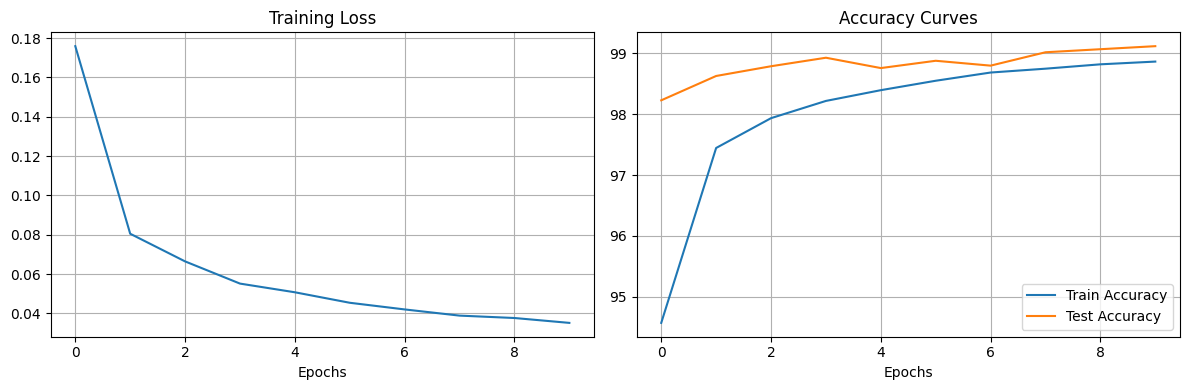

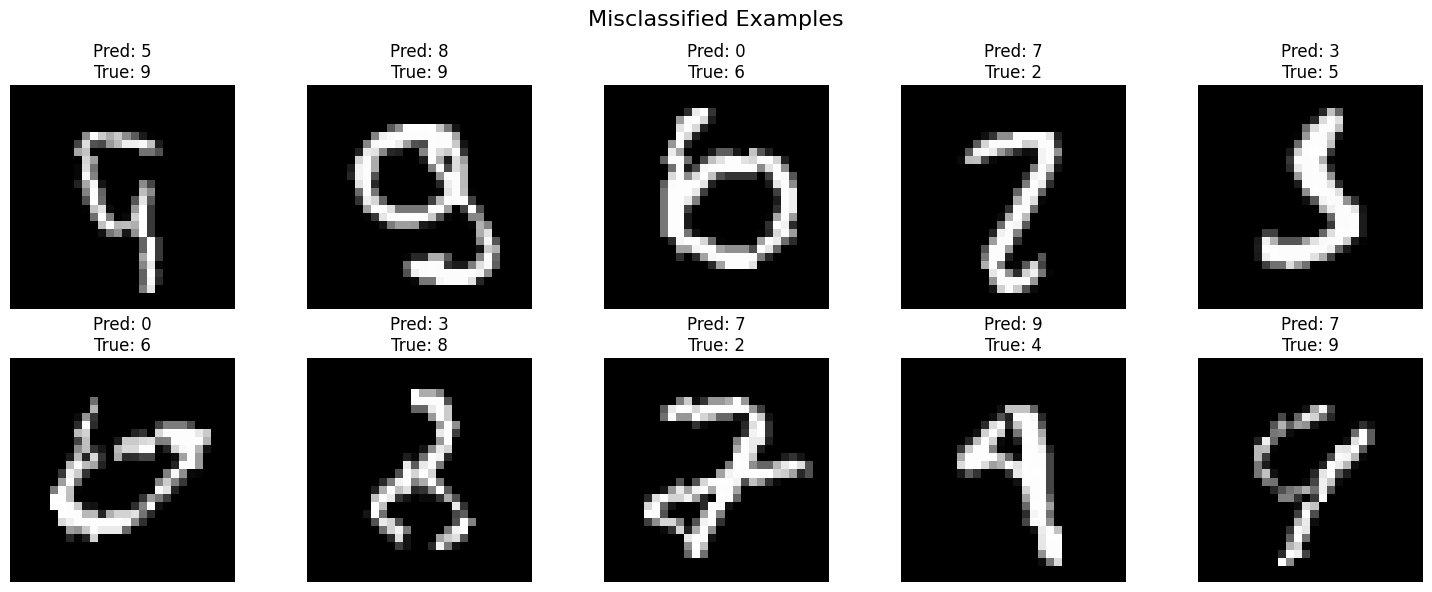

Model saved to enhanced_mnist_cnn.pth


In [7]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time

# 修正数据预处理（与截图一致）
transform = transforms.Compose([
    transforms.RandomRotation(10),  # 随机旋转增强
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST单通道均值/标准差
])

# 加载数据
train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4)
test_loader = DataLoader(test_data, batch_size=1000)

# 改进模型（修正维度错误）
class EnhancedCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),  # 修正输入/输出通道数
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 -> 14x14
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14 -> 7x7
            nn.Dropout(0.5)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

# 训练优化
device = "cuda" if torch.cuda.is_available() else "cpu"
model = EnhancedCNN().to(device)
optimizer = optim.Adam(model.parameters(), weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()

# === 可视化辅助函数 ===
def plot_loss_accuracy(train_losses, train_accs, test_accs):
    """绘制训练损失和准确率曲线"""
    plt.figure(figsize=(12, 4))
    
    # 损失曲线
    plt.subplot(121)
    plt.plot(train_losses, label='Training Loss')
    plt.title("Training Loss")
    plt.xlabel("Epochs")
    plt.grid(True)
    
    # 准确率曲线
    plt.subplot(122)
    plt.plot(train_accs, label='Train Accuracy')
    plt.plot(test_accs, label='Test Accuracy')
    plt.title("Accuracy Curves")
    plt.xlabel("Epochs")
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()

def show_misclassified(model, test_loader, n_samples=10):
    """展示错误分类的样本"""
    model.eval()
    misclassified = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            incorrect = preds != labels
            
            for i in torch.where(incorrect)[0]:
                if len(misclassified) < n_samples:
                    misclassified.append((
                        images[i].cpu(), 
                        preds[i].item(), 
                        labels[i].item()
                    ))
    
    # 绘制错误分类样本
    plt.figure(figsize=(15, 6))
    plt.suptitle("Misclassified Examples", fontsize=16)
    
    for idx, (img, pred, label) in enumerate(misclassified):
        plt.subplot(2, 5, idx+1)
        img = img.squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(f"Pred: {pred}\nTrue: {label}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# === 训练主循环 ===
train_losses = []
train_accs = []
test_accs = []

start_time = time.time()

for epoch in range(10):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # 反向传播
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # 统计信息
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    # 计算训练集准确率
    train_acc = 100 * correct / total
    train_accs.append(train_acc)
    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    # 评估测试集
    model.eval()
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()
    
    test_acc = 100 * test_correct / test_total
    test_accs.append(test_acc)
    
    # 打印训练进度
    print(f"Epoch [{epoch+1}/10] Loss: {avg_loss:.4f} "
          f"Train Acc: {train_acc:.2f}% "
          f"Test Acc: {test_acc:.2f}%")

# === 训练后可视化 ===
print(f"\nTotal training time: {time.time()-start_time:.2f} seconds")
plot_loss_accuracy(train_losses, train_accs, test_accs)
show_misclassified(model, test_loader, n_samples=10)

# 模型保存
torch.save(model.state_dict(), "enhanced_mnist_cnn.pth")
print("Model saved to enhanced_mnist_cnn.pth")